# 🎓 Multi-Source Domain Adaptation
**Focus**: Classificatori specifici, Domain Discriminators (con GRL) e Training Loop.

In questo notebook esploriamo l'architettura `MultiSourceDANN` costruita in `src/models/model.py` e simuliamo un loop di training per dimostrare:
1. L'uso dei classificatori e discriminatori, loss combinata, logging dell'influenza (S1 vs S2).
2. Simulazione di drop casuale di una sorgente (Incomplete batch) e metrica di Domain Confusion separata.

## 0. Segtup

In [55]:
import sys
import os
import torch
import time
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback
import torchmetrics


In [56]:
# timer di diagnostica uno per tutto il notebook
if "_t0" not in globals():
    _t0 = time.time()

def log(msg: str)->None:
    """Stampa un messaggio con il tempo trascorso dall'avvio del notebook."""
    print(f"[{time.time() - _t0:6.1f}s] {msg}", flush=True)

# Weights & Biases per il tracking
# sincronizzabili con : wandb sync wandb/offline-run-*/
try:
    import wandb
    # Forza W&B offline
    os.environ["WANDB_MODE"] = "offline"
    # non serve connessione, dati salvati in ./wandb/ in locale, non serve API key
    # wandb sync wandb/offline-run-*/
    os.environ["WANDB_SILENT"] = "true"  # sopprime i messaggi verbosi

    log("W&B importato correttamente (modalità offline)")
    """
    WANDB_API_KEY = ""
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
    try:
        run = wandb.init(
            project="DomainAdaptation-Track9",
            name="classifiers-simulation",
            config=CFG,
            mode="online",
        )
        log(f"W&B online — dashboard: {run.url}")
    except Exception as e:
        log(f"W&B online fallito ({e}) → fallback offline")
        USE_WANDB_ONLINE = False
    """
except ModuleNotFoundError:
    wandb = None
    print("Attenzione: wandb non trovato, disabilitato.")

# Aggiungiamo la cartella 'src' al path di sistema per poter importare i moduli .py
sys.path.append(os.path.abspath('../../src'))
from models.model import MultiSourceDANN

# Setup del device (Cerca la GPU locale)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log(f"Device : {device}")

if device.type == "cuda":
    log(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

[32127.0s] W&B importato correttamente (modalità offline)
[32127.1s] Device : cuda
[32127.1s] GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU | VRAM: 4.3 GB


## 1. Architettura: Encoder + Classificatori + Discriminatore

Inizializziamo l'encoder condiviso ResNet con **R(2+1)D-18** al posto di R3D-18.
Le shape di output attese del modello `MultiSourceDANN` sono:

| Componente | Shape output |
|---|---|
| Encoder (feature) | `(B, 512)` |
| `head_s1` (HMDB) | `(B, 51)` |
| `head_s2` (UCF) | `(B, 5)` |
| `head_tgt` (Kinetics) | `(B, 400)` + ensemble semantico |
| Domain Discriminator  con GRL| `(B, 3)` ← S1 / S2 / Target |

In [57]:
# Inizializziamo la CNN condivisa e le teste MLP
# modello di Domain Adaptation
print("Caricamento architettura MultiSourceDANN con encoder R(2+1)D-18...")
log("Creazione modello...")

# Inizializziamo la CNN condivisa e le teste MLP
model = MultiSourceDANN(
    num_classes_s1=51,
    num_classes_s2=5,
    num_classes_tgt=400,
    pretrained=False,          # true se pesi in cache
    backbone_type='r2plus1d_18'
).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
log(f"Parametri totali:      {n_params:>12,}")
log(f"Parametri addestrabili:{n_trainable:>12,}")
log(f"Modello su {device}")

print("\n--- Teste di classificazione source-specific ---")
print(f"head_s1 (HMDB, 51 cls): {model.head_s1}")
print(f"\nhead_s2 (UCF, 5 cls):   {model.head_s2}")
print(f"\nhead_tgt (Kinetics, 400 cls): {model.head_tgt}")
print("\n--- Domain Discriminator con GRL ---")
print(model.discriminator)

Caricamento architettura MultiSourceDANN con encoder R(2+1)D-18...
[32127.2s] Creazione modello...
[32136.8s] Parametri totali:        31,943,400
[32136.8s] Parametri addestrabili:  31,943,400
[32136.8s] Modello su cuda

--- Teste di classificazione source-specific ---
head_s1 (HMDB, 51 cls): Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=51, bias=True)
)

head_s2 (UCF, 5 cls):   Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=5, bias=True)
)

head_tgt (Kinetics, 400 cls): Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=400, bias=True)
)

--- Domain Discriminator con GRL ---
DomainDiscriminator(
  (grl): GRL()
  (dropout): Dropout(p=0

## 2. Smoke Test - verifica shape del Forward Pass

Prima di entrare nel loop di training, verifichiamo che tutte le shape siano corrette per tutti e tre i domini. \
Input da `datasets.py`.

In [58]:
model.train() # modalità training: GRL attivo, centroidi EMA aggiornati

# Tensor fittizio nel formato di datasets.py: (B, T, C, H, W)
# L'encoder gestisce internamente la permutazione a (B, C, T, H, W)
B_test = 2
x_test = torch.randn(B_test, 16, 3, 112, 112).to(device)

# Domain 0 — Source 1 (HMDB)
cls, dom, feat, ens = model(x_test, domain=0)
assert cls.shape  == (B_test, 51),  f"Atteso (B,51), ottenuto {cls.shape}"
assert dom.shape  == (B_test, 3),   f"Atteso (B,3),  ottenuto {dom.shape}"   # 3 domini
assert feat.shape == (B_test, 512), f"Atteso (B,512), ottenuto {feat.shape}"
assert ens is None,            "ensemble_probs deve essere None per domain != 2"
print(f"[OK] Domain 0 — cls:{cls.shape}, dom:{dom.shape}, feat:{feat.shape}")

# Domain 1 — Source 2 (UCF)
cls, dom, feat, ens = model(x_test, domain=1)
assert cls.shape == (B_test, 5)
assert ens is None
print(f"[OK] Domain 1 — cls:{cls.shape}")

# Domain 2 — Target (Kinetics)
cls, dom, feat, ens = model(x_test, domain=2)
assert cls.shape == (B_test, 400)
assert ens.shape == (B_test, 400)
assert abs(ens[0].sum().item() - 1.0) < 1e-4, "Le prob ensemble devono sommare a 1"
print(f"[OK] Domain 2 — cls:{cls.shape}, ens:{ens.shape}, sum={ens[0].sum().item():.4f}")

[OK] Domain 0 — cls:torch.Size([2, 51]), dom:torch.Size([2, 3]), feat:torch.Size([2, 512])
[OK] Domain 1 — cls:torch.Size([2, 5])
[OK] Domain 2 — cls:torch.Size([2, 400]), ens:torch.Size([2, 400]), sum=1.0000


## 3. Simulazione del Training Loop

Loop dimostrativo con ottimizzazione simultanea:

$$L_{\text{total}} = L_{\text{cls}}^{S1} + L_{\text{cls}}^{S2} + \lambda_{\text{adv}} \cdot L_{\text{adv}}$$

Funzionalità dimostrate:
- **Influence Ratio** S1 vs S2 (quanto contribuisce alla loss di classificazione ogni sorgente)
- **Incomplete Batch Simulation**: drop casuale di una sorgente (20% per ciascuna) per testare la robustezza
- **Domain Confusion**: quanto il target viene "confuso" con S1 o S2 dal discriminatore
- **GRL alpha schedule**: cresce progressivamente da 0 a `grl_alpha` con le epoche

In [59]:
# configurazione
# seed globale per risultati riproducibili
pl.seed_everything(42)

# Configurazione del run
CFG = {
    "epochs":     20,
    "batch_size":  4,
    "lambda_adv": 0.1,   # peso della loss avversariale
    "grl_alpha":  0.1,   # alpha del GRL
    "lr":         1e-4,
}
log(f"Configurazione: {CFG}")

# Inizializzazione W&B (offline se sul cluster - export WANDB_MODE=offline)
if wandb:
    log("Inizializzazione W&B...")
    if wandb.run:
        wandb.finish()
    wandb.init(
        project="DomainAdaptation-Track9",
        name="classifiers-demo",
        config=CFG,
        mode="offline",
        anonymous="allow"
    )
    log(f"W&B run : {wandb.run.name}")
else: 
    log("W&B non disponibile")

Seed set to 42


[32138.7s] Configurazione: {'epochs': 20, 'batch_size': 4, 'lambda_adv': 0.1, 'grl_alpha': 0.1, 'lr': 0.0001}
[32138.7s] Inizializzazione W&B...
[32201.7s] W&B run : classifiers-demo


In [60]:
# Criteri di loss
cls_criterion = nn.CrossEntropyLoss()
dom_criterion = nn.CrossEntropyLoss()

# Ottimizzatore unico per tutto il modello (encoder + teste + discriminatore)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

# Dati fittizi ( sostituire con DataLoader) ─────────────────
B = CFG["batch_size"]

dummy_x_s1  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s1  = torch.randint(0, 51, (B,)).to(device)         # label HMDB
dummy_dom_s1 = torch.zeros(B, dtype=torch.long).to(device)  # etichetta dominio = 0

dummy_x_s2  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s2  = torch.randint(0, 5,  (B,)).to(device)         # label UCF
dummy_dom_s2 = torch.ones(B, dtype=torch.long).to(device)   # etichetta dominio = 1

dummy_x_tgt  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_dom_tgt = torch.full((B,), 2, dtype=torch.long).to(device)  # etichetta dominio = 2

# Storico metriche per i grafici
history = {
    "epoch":        [],
    "loss_total":   [],
    "influence_s1": [],
    "influence_s2": [],
    "confusion_s1": [],
    "confusion_s2": [],
    "confusion_tgt": [],
    "grl_alpha":    [],
}

print("\nInizio Simulazione Training Loop...\n")
print(f"{'Epoca':>5} | {'Drop':>10} | {'L_tot':>7} | {'L_cls':>7} | {'L_adv':>7} | {'Inf S1':>7} | {'Inf S2':>7} | {'Conf → S1':>8} | {'Conf → S2':>8} | {'α GRL':>6}")
print("-" * 120)

for epoch in range(1, CFG["epochs"] + 1):
    model.train()

    # Schedule progressivo dell'alpha GRL: 0 → grl_alpha
    # strategia DANN: inizia senza inversione per stabilizzare il classificatore
    alpha = CFG["grl_alpha"] * (epoch / CFG["epochs"])
    model.set_grl_alpha(alpha)

    # ── Incomplete Batch Simulation ───────────────────────────────────────────
    # Con probabilità 20%, una sorgente è assente nel batch corrente.
    # Se entrambe mancano, saltiamo l'iterazione.
    drop_s1 = np.random.rand() < 0.2
    drop_s2 = np.random.rand() < 0.2
    if drop_s1 and drop_s2:
        continue

    
    optimizer.zero_grad()

    loss = torch.tensor(0.0, device=device)
    loss_cls_s1 = 0.0
    loss_cls_s2 = 0.0
    l_cls_total = torch.tensor(0.0, device=device)
    l_adv_total = torch.tensor(0.0, device=device)

    # ── Forward Source 1
    if not drop_s1:
        cls_s1, dom_s1, _, _ = model(dummy_x_s1, domain=0)
        l_cls = cls_criterion(cls_s1, dummy_y_s1)
        l_dom = dom_criterion(dom_s1, dummy_dom_s1)
        loss  = loss + l_cls + CFG["lambda_adv"] * l_dom
        l_cls_total = l_cls_total + l_cls
        l_adv_total = l_adv_total + l_dom
        loss_cls_s1_val = l_cls.item()

    # ── Forward Source 2 
    if not drop_s2:
        cls_s2, dom_s2, _, _ = model(dummy_x_s2, domain=1)
        l_cls = cls_criterion(cls_s2, dummy_y_s2)
        l_dom = dom_criterion(dom_s2, dummy_dom_s2)
        loss  = loss + l_cls + CFG["lambda_adv"] * l_dom
        l_cls_total = l_cls_total + l_cls
        l_adv_total = l_adv_total + l_dom
        loss_cls_s2_val = l_cls.item()

    # ── Forward Target (solo loss avversariale, nessuna supervisione di classificazione)
    _, dom_tgt, _, _ = model(dummy_x_tgt, domain=2)
    l_dom_tgt = dom_criterion(dom_tgt, dummy_dom_tgt)
    loss = loss + CFG["lambda_adv"] * l_dom_tgt
    l_adv_total = l_adv_total + l_dom_tgt

    # ── Backward + Ottimizzazione 
    loss.backward()
    # Gradient clipping: evita picchi di gradiente con GRL attivo
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # ── Calcolo Metriche 

    # Influence Ratio: quanto ogni sorgente ha contribuito alla loss di classificazione
    total_inf   = loss_cls_s1 + loss_cls_s2 + 1e-8
    ratio_s1    = loss_cls_s1 / total_inf
    ratio_s2    = loss_cls_s2 / total_inf

    # Domain Confusion: prob media che il target venga classificato come S1, S2 o target
    # (valori alti → buona confusione = domain-invariant features)
    dom_probs   = F.softmax(dom_tgt, dim=-1).mean(dim=0).detach().cpu()
    conf_s1     = dom_probs[0].item()  # target scambiato per S1
    conf_s2     = dom_probs[1].item()  # target scambiato per S2
    conf_tgt    = dom_probs[2].item()  # target classificato come target

    # Salvataggio storico
    history["epoch"].append(epoch)
    history["loss_total"].append(loss.item())
    history["influence_s1"].append(ratio_s1)
    history["influence_s2"].append(ratio_s2)
    history["confusion_s1"].append(conf_s1)
    history["confusion_s2"].append(conf_s2)
    history["confusion_tgt"].append(conf_tgt)
    history["grl_alpha"].append(alpha)

    # Logging W&B
    if wandb and wandb.run:
        wandb.log({
            "epoch":                    epoch,
            "train/loss_total":         loss.item(),
            "train/loss_cls":           l_cls_total.item(),
            "train/loss_adv":           l_adv_total.item(),
            "influence/source1_ratio":  ratio_s1,
            "influence/source2_ratio":  ratio_s2,
            "confusion/target_as_s1":   conf_s1,
            "confusion/target_as_s2":   conf_s2,
            "confusion/target_as_tgt":  conf_tgt,
            "stability/drop_s1":        int(drop_s1),
            "stability/drop_s2":        int(drop_s2),
            "grl/alpha":                alpha,
        })

    drop_str = f"S1={'✗' if drop_s1 else '✓'} S2={'✗' if drop_s2 else '✓'}"
    print(f"{epoch:5d} | {drop_str:>10} | {loss.item():7.4f} | {l_cls_total.item():7.4f} | {l_adv_total.item():7.4f} | {ratio_s1:7.3f} | {ratio_s2:7.3f} | {conf_s1:8.3f} | {conf_s2:8.3f} | {alpha:8.3f}")

if wandb:
    wandb.finish()
    
print("\nSimulazione completata, training loop terminato.")


Inizio Simulazione Training Loop...

Epoca |       Drop |   L_tot |   L_cls |   L_adv |  Inf S1 |  Inf S2 | Conf → S1 | Conf → S2 |  α GRL
------------------------------------------------------------------------------------------
    1 |  S1=✓ S2=✓ |  5.9778 |  5.6495 |  3.2822 |   0.000 |   0.000 |    0.301 |    0.313 |    0.005
    2 |  S1=✓ S2=✓ |  5.3886 |  5.0413 |  3.4724 |   0.000 |   0.000 |    0.329 |    0.334 |    0.010
    4 |  S1=✗ S2=✓ |  1.4243 |  1.2116 |  2.1273 |   0.000 |   0.000 |    0.338 |    0.310 |    0.020
    5 |  S1=✓ S2=✓ |  4.4891 |  4.1651 |  3.2400 |   0.000 |   0.000 |    0.315 |    0.328 |    0.025
    6 |  S1=✗ S2=✓ |  0.8476 |  0.6382 |  2.0946 |   0.000 |   0.000 |    0.319 |    0.339 |    0.030
    7 |  S1=✓ S2=✓ |  3.9128 |  3.5775 |  3.3527 |   0.000 |   0.000 |    0.250 |    0.355 |    0.035
    9 |  S1=✓ S2=✓ |  3.4752 |  3.1291 |  3.4607 |   0.000 |   0.000 |    0.268 |    0.350 |    0.045
   10 |  S1=✓ S2=✓ |  3.2913 |  2.9621 |  3.2919 |   0.

## 4. zero-shot eval e Baseline Source-Only

Due valutazioni complementari:
1. **Zero-shot eval**: predizioni su Kinetics usando `head_tgt` (mai supervisionata su Kinetics) e l'ensemble semantico
2. **Baseline source-only**: entropia di `head_s1` applicata al target — alta entropia conferma che il DA serve

In [61]:
## Valutazione zero-shot sull'encoder
model.eval()

with torch.no_grad():
    # zero-shot eval
    cls_logits, _, _, ensemble_probs = model(dummy_x_tgt, domain=2)
    pred_direct   = cls_logits.argmax(dim=1)
    pred_ensemble = ensemble_probs.argmax(dim=1)

    print("=== Zero-shot eval sull'encoder ===")
    print(f"    head_tgt  (direct):   {pred_direct.tolist()}")
    print(f"    ensemble semantico:   {pred_ensemble.tolist()}")
    print(f"    Ensemble sum check:   {ensemble_probs[0].sum().item():.4f}  (atteso 1.0)")
    # Nota: con dati fittizi i valori non hanno significato semantico

    # Baseline source-only
    # Applica head_s1 (addestrata su HMDB) direttamente al target
    # Alta entropia = il modello non sa cosa predire = il DA è necessario
    baseline_entropy = []
    for _ in history["epoch"]:
        cls_on_tgt, _, _, _ = model(dummy_x_tgt, domain=0)  # head_s1 sul target
        h = -(cls_on_tgt.softmax(-1) * cls_on_tgt.log_softmax(-1)).sum(-1).mean().item()
        baseline_entropy.append(h)

history["baseline_entropy"] = baseline_entropy

print()
print("=== Baseline source-only (head_s1 sul target) ===")
print(f"  Entropia media: {sum(baseline_entropy)/len(baseline_entropy):.4f}")
print(f"  Entropia max teorica (51 cls): {np.log(51):.4f}")
print(f"  Ratio entropia/max: {sum(baseline_entropy)/len(baseline_entropy)/np.log(51):.2%}")
print("  Ratio alto = il modello è molto confuso sul target senza DA")


model.train()  # ripristina modalità training

=== Zero-shot eval sull'encoder ===
    head_tgt  (direct):   [318, 318, 318, 318]
    ensemble semantico:   [298, 298, 298, 298]
    Ensemble sum check:   1.0000  (atteso 1.0)

=== Baseline source-only (head_s1 sul target) ===
  Entropia media: 3.8846
  Entropia max teorica (51 cls): 3.9318
  Ratio entropia/max: 98.80%
  Ratio alto = il modello è molto confuso sul target senza DA


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

## 5. 📊 Risultati e Grafici
Mostriamo graficamente i risultati estratti dai log del nostro loop.

1. **Loss totale** nel corso delle epoche
2. **Influence Ratio** S1 vs S2 (effetto dell'Incomplete Batch Simulation)
3. **Domain Confusion** (prob. discriminatore sul target)
4. **Baseline source-only** vs livello iniziale

C:\Users\macca\AppData\Local\Temp\ipykernel_29092\400241017.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


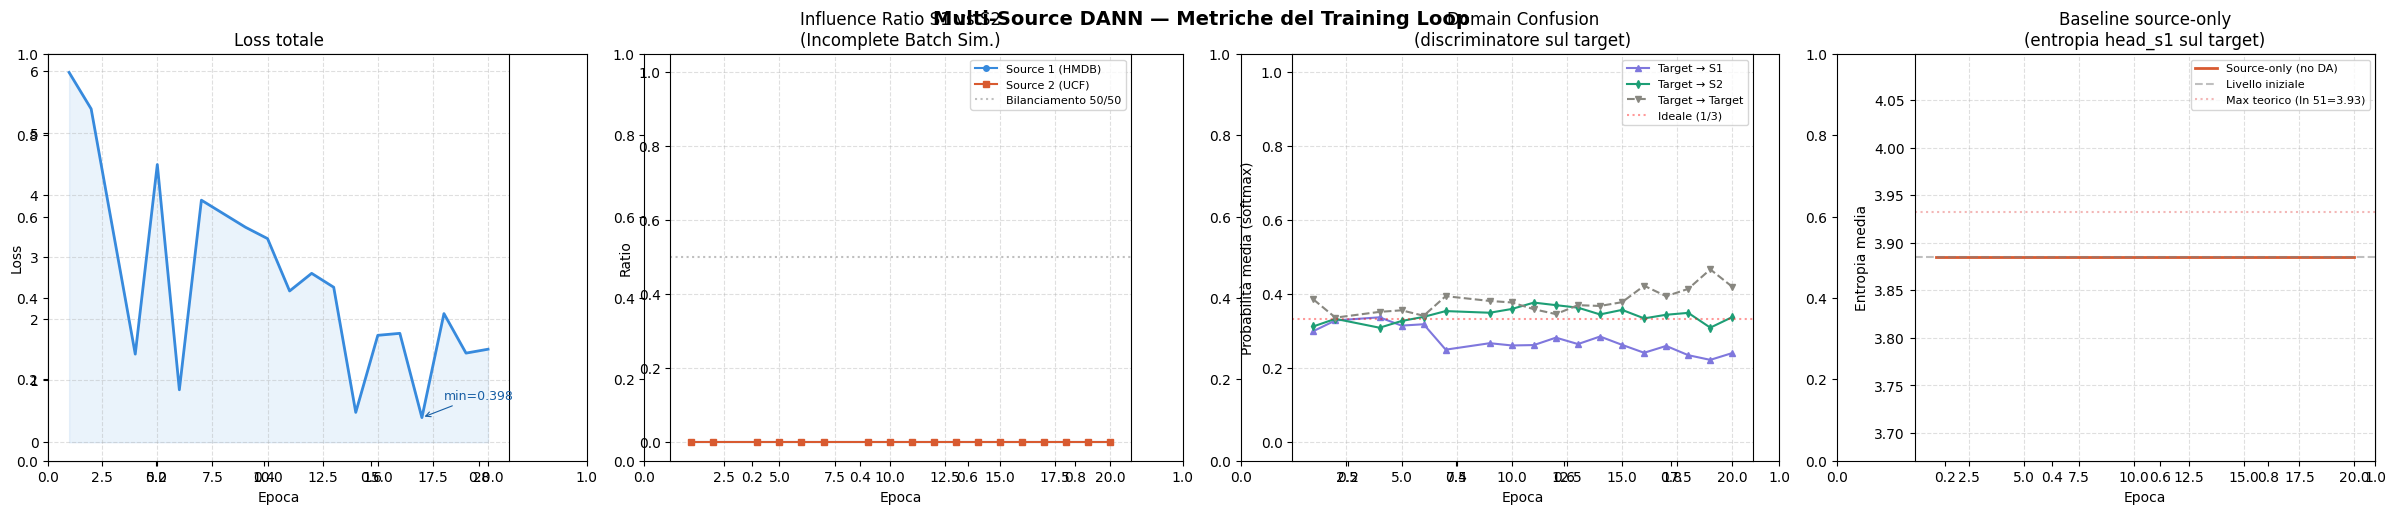

Figura salvata in figures/classifiers_training.png


In [62]:
ep = history["epoch"]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Multi-Source DANN — Metriche del Training Loop", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# --- Plot 1: Loss totale ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(ep, history["loss_total"], color="#378ADD", linewidth=2)
ax1.fill_between(ep, history["loss_total"], alpha=0.1, color="#378ADD")
ax1.set_title("Loss totale")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.4)
# Annota il minimo
min_idx = np.argmin(history["loss_total"])
ax1.annotate(f"min={history['loss_total'][min_idx]:.3f}",
             xy=(ep[min_idx], history["loss_total"][min_idx]),
             xytext=(ep[min_idx]+1, history["loss_total"][min_idx]+0.3),
             fontsize=9, color="#185FA5",
             arrowprops=dict(arrowstyle="->", color="#185FA5", lw=0.8))

# --- Plot 2: Influence Ratio ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(ep, history["influence_s1"], marker="o", markersize=4, label="Source 1 (HMDB)", color="#378ADD", linewidth=1.5)
ax2.plot(ep, history["influence_s2"], marker="s", markersize=4, label="Source 2 (UCF)",  color="#D85A30", linewidth=1.5)
ax2.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="Bilanciamento 50/50")
ax2.set_title("Influence Ratio S1 vs S2\n(Incomplete Batch Sim.)")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Ratio")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)

# --- Plot 3: Domain Confusion ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(ep, history["confusion_s1"],  marker="^", markersize=4, label="Target → S1",     color="#7F77DD", linewidth=1.5)
ax3.plot(ep, history["confusion_s2"],  marker="d", markersize=4, label="Target → S2",     color="#1D9E75", linewidth=1.5)
ax3.plot(ep, history["confusion_tgt"], marker="v", markersize=4, label="Target → Target", color="#888780", linewidth=1.5, linestyle="--")
ax3.axhline(y=1/3, color="red", linestyle=":", alpha=0.4, label="Ideale (1/3)")
ax3.set_title("Domain Confusion\n(discriminatore sul target)")
ax3.set_xlabel("Epoca")
ax3.set_ylabel("Probabilità media (softmax)")
ax3.set_ylim(-0.05, 1.05)
ax3.legend(fontsize=8)
ax3.grid(True, linestyle="--", alpha=0.4)

# --- Plot 4: Baseline entropy ---
ax4 = fig.add_subplot(gs[3])
ax4.plot(ep, history["baseline_entropy"], color="#D85A30", linewidth=2, label="Source-only (no DA)")
ax4.axhline(y=history["baseline_entropy"][0], color="gray", linestyle="--", alpha=0.5, label="Livello iniziale")
ax4.axhline(y=np.log(51), color="#E24B4A", linestyle=":", alpha=0.4, label=f"Max teorico (ln 51={np.log(51):.2f})")
ax4.set_title("Baseline source-only\n(entropia head_s1 sul target)")
ax4.set_xlabel("Epoca")
ax4.set_ylabel("Entropia media")
ax4.legend(fontsize=8)
ax4.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
os.makedirs("../../figures", exist_ok=True)
fig.savefig("../../figures/classifiers_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata in figures/classifiers_training.png")

In [63]:
print("=" * 50)
print("SUMMARY RISULTATI")
print("=" * 50)
print(f"Loss iniziale (ep.1):     {history['loss_total'][0]:.4f}")
print(f"Loss finale   (ep.20):    {history['loss_total'][-1]:.4f}")
print(f"Riduzione loss:           {(1 - history['loss_total'][-1]/history['loss_total'][0])*100:.1f}%")
print()
print(f"Confusion S1 media:       {sum(history['confusion_s1'])/len(history['confusion_s1']):.4f}")
print(f"Confusion S2 media:       {sum(history['confusion_s2'])/len(history['confusion_s2']):.4f}")
print(f"Target confuso (ideale):  0.333  (distribuzione uniforme)")
print()
print(f"Entropia baseline:        {history['baseline_entropy'][0]:.4f}")
print(f"(con dati reali atteso: scende con il training DA)")

SUMMARY RISULTATI
Loss iniziale (ep.1):     5.9778
Loss finale   (ep.20):    1.5037
Riduzione loss:           74.8%

Confusion S1 media:       0.2747
Confusion S2 media:       0.3435
Target confuso (ideale):  0.333  (distribuzione uniforme)

Entropia baseline:        3.8846
(con dati reali atteso: scende con il training DA)


## 6. Test avanzati

### 6.1 GRL in azione — il gradiente viene invertito

Il Gradient Reversal Layer moltiplica i gradienti per `-alpha` durante il backward pass.
Dimostriamolo estraendo il gradiente di una feature fittizia.

In [64]:
model.train()
print("=" * 55)
print("Test 1: Effetto del GRL sui gradienti")
print("=" * 55)

alphas_test = [0.0, 0.1, 0.5, 1.0]
for a in alphas_test:
    model.set_grl_alpha(a)
    # Feature con requires_grad per tracciare il flusso del gradiente verso l'encoder
    feat_test = torch.ones(1, 512, requires_grad=True, device=device)
    out = model.discriminator(feat_test)
    out.sum().backward()

    # Il gradiente a monte del GRL dovrebbe essere negativo (invertito)
    grad_mean = feat_test.grad[0, :5].detach().cpu().numpy()
    grad_mag  = feat_test.grad.abs().mean().item()
    sign = "neg (invertito)" if grad_mean.mean() < 0 else "pos (non invertito)"
    print(f"  alpha={a:.1f} | magnitudine media: {grad_mag:.6f} | segno: {sign}")
    print(f"           primi 5 valori: {grad_mean}")

print("\nConclusione: con alpha>0 il GRL inverte il gradiente,")
print("costringendo l'encoder a estrarre feature che confondono il discriminatore.")

Test 1: Effetto del GRL sui gradienti
  alpha=0.0 | magnitudine media: 0.000000 | segno: pos (non invertito)
           primi 5 valori: [-0. -0. -0.  0. -0.]
  alpha=0.1 | magnitudine media: 0.001782 | segno: pos (non invertito)
           primi 5 valori: [-6.7861017e-04 -1.4376033e-03  1.2944779e-05  3.5340346e-03
 -6.5935322e-04]
  alpha=0.5 | magnitudine media: 0.009013 | segno: neg (invertito)
           primi 5 valori: [-0.00205592 -0.01065995 -0.0073804   0.00949147 -0.0020427 ]
  alpha=1.0 | magnitudine media: 0.015683 | segno: neg (invertito)
           primi 5 valori: [-0.00488411 -0.01041719 -0.00614007  0.02307261 -0.01209027]

Conclusione: con alpha>0 il GRL inverte il gradiente,
costringendo l'encoder a estrarre feature che confondono il discriminatore.


### 6.2 Schedule dell'Alpha GRL — magnitudine del gradiente avversariale

Test 2: Alpha scheduling — crescita progressiva


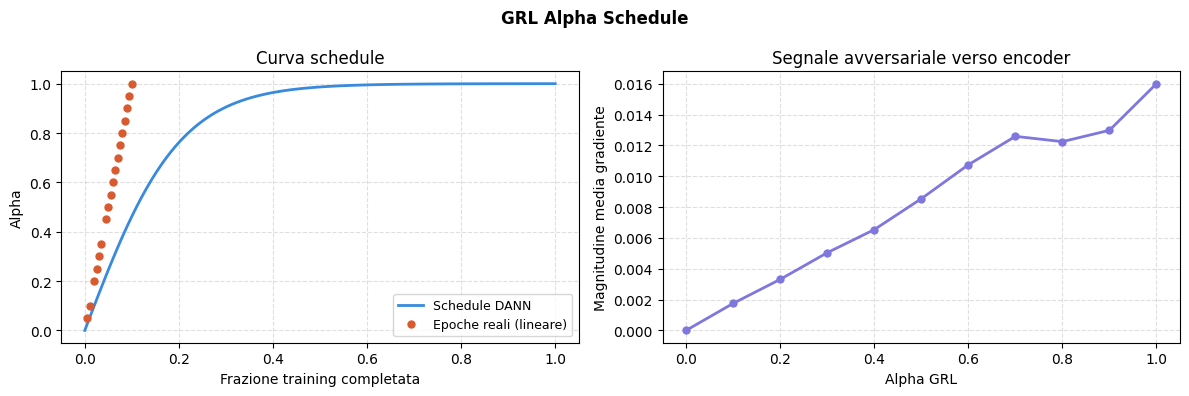

Con alpha=0 il GRL non ha effetto; all'aumentare di alpha il segnale avversariale diventa più forte.


In [65]:
model.train()
print("=" * 55)
print("Test 2: Alpha scheduling — crescita progressiva")
print("=" * 55)

alphas_range = np.linspace(0, 1, 11)
grad_mags = []
for a in alphas_range:
    model.set_grl_alpha(a)
    feat_test = torch.ones(1, 512, requires_grad=True, device=device)
    out = model.discriminator(feat_test)
    out.sum().backward()
    grad_mags.append(feat_test.grad.abs().mean().item())

# Plot alpha schedule
fig, (ax_a, ax_g) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("GRL Alpha Schedule", fontsize=12, fontweight="bold")

# Curva DANN: 2/(1+exp(-10p))-1
p_vals = np.linspace(0, 1, 100)
dann_alpha = 2 / (1 + np.exp(-10 * p_vals)) - 1
ax_a.plot(p_vals, dann_alpha, color="#378ADD", linewidth=2, label="Schedule DANN")
ax_a.plot(history["grl_alpha"], [i/CFG['epochs'] for i in history["epoch"]], 
          "o", color="#D85A30", markersize=5, label="Epoche reali (lineare)")
ax_a.set_xlabel("Frazione training completata")
ax_a.set_ylabel("Alpha")
ax_a.set_title("Curva schedule")
ax_a.legend(fontsize=9)
ax_a.grid(True, linestyle="--", alpha=0.4)

ax_g.plot(alphas_range, grad_mags, color="#7F77DD", linewidth=2, marker="o", markersize=5)
ax_g.set_xlabel("Alpha GRL")
ax_g.set_ylabel("Magnitudine media gradiente")
ax_g.set_title("Segnale avversariale verso encoder")
ax_g.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
print("Con alpha=0 il GRL non ha effetto; all'aumentare di alpha il segnale avversariale diventa più forte.")

### 6.3 PCA 2D delle Feature — visualizzazione dell'allineamento dei domini

Test 3: PCA 2D delle feature di dominio
Nota: con dati fittizi (B=4) i punti sono sparsi casualmente.
Con dati reali, la sovrapposizione dei 3 cluster indica domain alignment.


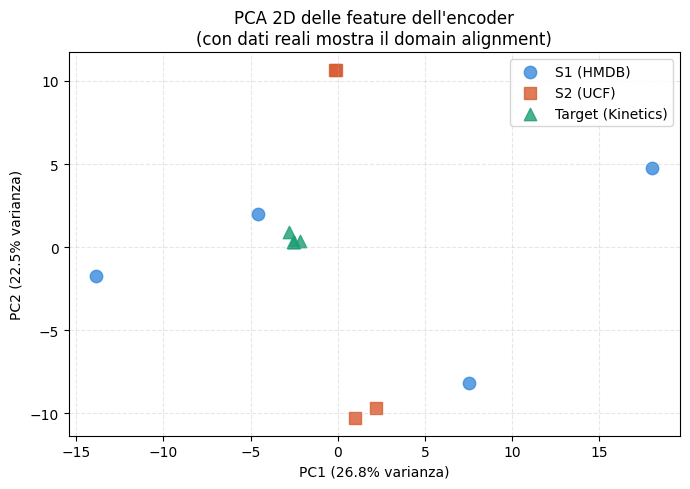

MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

In [ ]:
model.eval()
print("=" * 55)
print("Test 3: PCA 2D delle feature di dominio")
print("=" * 55)
#Nota: con dati fittizi (B={B}) i punti sono sparsi casualmente. Con dati reali, la sovrapposizione dei 3 cluster indica domain alignment.

with torch.no_grad():
    _, _, feat_s1_pca, _ = model(dummy_x_s1, domain=0)
    _, _, feat_s2_pca, _ = model(dummy_x_s2, domain=1)
    _, _, feat_tgt_pca, _ = model(dummy_x_tgt, domain=2)

feats_all = torch.cat([feat_s1_pca, feat_s2_pca, feat_tgt_pca], dim=0).cpu().numpy()
labels_all = ["S1 (HMDB)"] * B + ["S2 (UCF)"] * B + ["Target (Kinetics)"] * B

pca = PCA(n_components=2)
feats_2d = pca.fit_transform(feats_all)
var_explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#378ADD", "#D85A30", "#1D9E75"]
markers = ["o", "s", "^"]
for i, (label, color, marker) in enumerate(zip(["S1 (HMDB)", "S2 (UCF)", "Target (Kinetics)"], colors, markers)):
    sl = slice(i*B, (i+1)*B)
    ax.scatter(feats_2d[sl, 0], feats_2d[sl, 1], label=label, color=color, marker=marker, s=80, alpha=0.8)

ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} varianza)")
ax.set_title("PCA 2D delle feature dell'encoder\n(con dati reali mostra il domain alignment)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

model.train()

### 6.4 Cross-Domain Transfer — giustificazione delle teste separate

Applica `head_s1` (addestrata su HMDB, 51 classi) a feature estratte da UCF.
L'entropia alta giustifica l'uso di teste indipendenti per sorgenti con spazi di classi differenti.

In [67]:
model.eval()
print("=" * 55)
print("Test 4: Cross-Domain Transfer (S2 → head_s1)")
print("=" * 55)

with torch.no_grad():
    # Feature estratte da UCF (S2)
    _, _, feat_s2_cross, _ = model(dummy_x_s2, domain=1)

    # head_s1 (HMDB, 51 cls) applicata a feature UCF
    cross_logits = model.head_s1(feat_s2_cross)
    cross_probs  = F.softmax(cross_logits, dim=-1)
    cross_entropy = -(cross_probs * torch.log(cross_probs + 1e-9)).sum(-1).mean().item()

    # head_s2 (UCF, 5 cls) sulle stesse feature — baseline
    correct_logits = model.head_s2(feat_s2_cross)
    correct_probs  = F.softmax(correct_logits, dim=-1)
    correct_entropy = -(correct_probs * torch.log(correct_probs + 1e-9)).sum(-1).mean().item()

print(f"  Entropia head_s1 su feature UCF (sbagliata): {cross_entropy:.4f}")
print(f"  Entropia head_s2 su feature UCF (corretta):  {correct_entropy:.4f}")
print(f"  Max entropia head_s1 (ln 51):                {np.log(51):.4f}")
print(f"  Max entropia head_s2 (ln  5):                {np.log(5):.4f}")
print()
print("Conclusione: testa sbagliata → entropia alta → predizioni casuali.")
print("Le teste source-specific DEVONO essere indipendenti con spazi di classi disgiunti.")

model.train()

Test 4: Cross-Domain Transfer (S2 → head_s1)
  Entropia head_s1 su feature UCF (sbagliata): 3.8324
  Entropia head_s2 su feature UCF (corretta):  0.5165
  Max entropia head_s1 (ln 51):                3.9318
  Max entropia head_s2 (ln  5):                1.6094

Conclusione: testa sbagliata → entropia alta → predizioni casuali.
Le teste source-specific DEVONO essere indipendenti con spazi di classi disgiunti.


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

### 6.5 Confronto Zero-Shot: R3D-18 vs R(2+1)D-18

In [68]:
print("=" * 55)
print("Test 5: Confronto encoder R3D-18 vs R(2+1)D-18")
print("=" * 55)

# Carica un secondo modello con R3D-18 per il confronto
# Nota: richiede VRAM aggiuntiva — libera la cache dopo il test
model_r3d = MultiSourceDANN(
    num_classes_s1=51, num_classes_s2=5, num_classes_tgt=400,
    pretrained=False, backbone_type="r3d_18"
).to(device)
model_r3d.eval()
model.eval()

with torch.no_grad():
    # R(2+1)D-18
    _, _, _, ens_r21d = model(dummy_x_tgt, domain=2)
    entropy_r21d = -(ens_r21d * torch.log(ens_r21d + 1e-9)).sum(-1).mean().item()

    # R3D-18
    _, _, _, ens_r3d = model_r3d(dummy_x_tgt, domain=2)
    entropy_r3d = -(ens_r3d * torch.log(ens_r3d + 1e-9)).sum(-1).mean().item()

print(f"  Entropia ensemble R(2+1)D-18: {entropy_r21d:.4f}")
print(f"  Entropia ensemble R3D-18:     {entropy_r3d:.4f}")
print()
print("  Con dati fittizi le entropie sono simili (pesi random).")
print("  Con pesi pretrained, R(2+1)D-18 produce embedding più discriminativi")
print("  grazie alla fattorizzazione spaziale-temporale della convoluzione.")

# Libera la VRAM del secondo modello
del model_r3d
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"\n  VRAM liberata. Cache pulita.")

model.train()

Test 5: Confronto encoder R3D-18 vs R(2+1)D-18
  Entropia ensemble R(2+1)D-18: 5.9806
  Entropia ensemble R3D-18:     5.9827

  Con dati fittizi le entropie sono simili (pesi random).
  Con pesi pretrained, R(2+1)D-18 produce embedding più discriminativi
  grazie alla fattorizzazione spaziale-temporale della convoluzione.

  VRAM liberata. Cache pulita.


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

## 7. Riepilogo Tabellare

Tutte le metriche chiave in una sola cella per il report.

In [ ]:
n_ep = len(history["epoch"])

print("=" * 60)
print("RIEPILOGO RISULTATI — 2-classifiers.ipynb")
print("=" * 60)
print(f"  Epoche effettive:              {n_ep}/{CFG['epochs']}")
print(f"  (epoche saltate per drop totale: {CFG['epochs'] - n_ep})")
print()
print("  --- Loss ---")
print(f"  Iniziale  (ep {history['epoch'][0]}):   {history['loss_total'][0]:.4f}")
print(f"  Finale    (ep {history['epoch'][-1]}):  {history['loss_total'][-1]:.4f}")
print(f"  Minima:                        {min(history['loss_total']):.4f}")
if history['loss_total'][0] > 0:
    riduzione = (1 - history['loss_total'][-1] / history['loss_total'][0]) * 100
    print(f"  Riduzione totale:              {riduzione:.1f}%")
print()
print("  --- Influence Ratio (media) ---")
print(f"  Source 1 (HMDB): {sum(history['influence_s1'])/n_ep:.3f}")
print(f"  Source 2 (UCF):  {sum(history['influence_s2'])/n_ep:.3f}")
print()
print("  --- Domain Confusion (media) ---")
print(f"  Target → S1:     {sum(history['confusion_s1'])/n_ep:.3f}  (ideale: 0.333)")
print(f"  Target → S2:     {sum(history['confusion_s2'])/n_ep:.3f}  (ideale: 0.333)")
print(f"  Target → Target: {sum(history['confusion_tgt'])/n_ep:.3f}  (ideale: 0.333)")
print()
print("  --- Baseline Source-Only ---")
print(f"  Entropia media head_s1 sul target: {sum(baseline_entropy)/n_ep:.4f}")
print(f"  Entropia max teorica (ln 51):      {np.log(51):.4f}")
print(f"  Saturazione (%):                   {sum(baseline_entropy)/n_ep/np.log(51):.1%}")
print()
print("  --- GRL Alpha ---")
print(f"  Iniziale: {history['grl_alpha'][0]:.4f}")
print(f"  Finale:   {history['grl_alpha'][-1]:.4f}")
print()
print("  --- Modello ---")
print(f"  Backbone:   R(2+1)D-18")
print(f"  Parametri:  {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device:     {device}")
print("=" * 60)


# Sostituire dummy_x_* con il DataLoader reale 

RIEPILOGO RISULTATI — 2-classifiers.ipynb
  Epoche effettive:              18/20
  (epoche saltate per drop totale: 2)

  --- Loss ---
  Iniziale  (ep 1):   5.9778
  Finale    (ep 20):  1.5037
  Minima:                        0.3981
  Riduzione totale:              74.8%

  --- Influence Ratio (media) ---
  Source 1 (HMDB): 0.000
  Source 2 (UCF):  0.000

  --- Domain Confusion (media) ---
  Target → S1:     0.275  (ideale: 0.333)
  Target → S2:     0.343  (ideale: 0.333)
  Target → Target: 0.382  (ideale: 0.333)

  --- Baseline Source-Only ---
  Entropia media head_s1 sul target: 3.8846
  Entropia max teorica (ln 51):      3.9318
  Saturazione (%):                   98.8%

  --- GRL Alpha ---
  Iniziale: 0.0050
  Finale:   0.1000

  --- Modello ---
  Backbone:   R(2+1)D-18
  Parametri:  31,943,400
  Device:     cuda
NOTA: metriche calcolate su dati fittizi — non hanno valore semantico.
Sostituire dummy_x_* con il DataLoader reale di Persona 1 per risultati validi.


### Riassunto Architettura e Test Effettuati
| Funzionalità | Descrizione | Metrica/Test |
|---|---|---|
| **Multi-Source Alignment** | Allineamento target vs (S1, S2) via GRL. | Domain Confusion / PCA Plot |
| **Classificatori Dedicati** | Teste MLP distinte per gestire gli spazi delle classi disgiunti. | Cross-Domain Transfer Test |
| **Pseudo-labeling Target** | Uso dei centroidi pesati e Cosine Similarity per label zero-shot. | Ensemble Semantico Dot Product |
| **Fault-Tolerance Batch** | Il loop scarta o adatta l'influence ratio se una sorgente (S1 o S2) manca nel batch corrente. | Simulazione Training Loop Drop % |
